# Challenge — Red neuronal con Keras 3
### Universidad EAFIT | SI3003 — Introducción a la Inteligencia Artificial

---

## Objetivo

En clase construimos una red neuronal para clasificación de imágenes usando **Keras 3**.

En este ejercicio aplicarás **la misma receta** sobre un dataset diferente: **CIFAR-10 convertido a escala de grises**.

No necesitas diseñar un pipeline nuevo. La descarga, conversión a escala de grises y visualización están resueltas. Tu trabajo es completar únicamente las etapas de Keras que vimos en clase:

```text
Datos → Normalización → Modelo → Loss + Optimizer → fit() → evaluate() → Predicción
```

Las celdas marcadas con `# TODO` son las que debes completar.


---
## 0. Librerías


In [1]:
import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
keras.utils.set_random_seed(SEED)

print(f"Keras version : {keras.__version__}")
print(f"Backend       : {keras.backend.backend()}")


Keras version : 3.13.2
Backend       : tensorflow


---
# 1. Dataset: CIFAR-10

CIFAR-10 contiene 50,000 imágenes de entrenamiento y 10,000 de prueba. Las imágenes originales son de **32×32×3** y pertenecen a 10 categorías:

`airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck`.


In [2]:
# Esta parte está resuelta.
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

y_train = y_train.squeeze()
y_test = y_test.squeeze()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("X_train original:", X_train.shape)
print("X_test original :", X_test.shape)
print("y_train         :", y_train.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2201s 13us/step
X_train original: (50000, 32, 32, 3)
X_test original : (10000, 32, 32, 3)
y_train         : (50000,)


## 1.1 RGB → escala de grises

Usaremos la transformación:

$$Gray = 0.299R + 0.587G + 0.114B$$

Esta parte está resuelta porque el objetivo del ejercicio es practicar Keras.


In [3]:
X_train = (
    0.299 * X_train[..., 0] +
    0.587 * X_train[..., 1] +
    0.114 * X_train[..., 2]
)

X_test = (
    0.299 * X_test[..., 0] +
    0.587 * X_test[..., 1] +
    0.114 * X_test[..., 2]
)

print("X_train grayscale:", X_train.shape)
print("X_test grayscale :", X_test.shape)


X_train grayscale: (50000, 32, 32)
X_test grayscale : (10000, 32, 32)


### Pregunta 1

Después de convertir las imágenes a escala de grises, cada imagen tiene tamaño `32×32`.

¿Cuántos valores tendrá cada imagen después de aplicar `Flatten()`?

**Respuesta:** 1024



## 1.2 Normalización

Los valores de los píxeles están entre 0 y 255. Completa el código para llevarlos al rango `[0,1]`.


In [4]:
# TODO 1 — Normalización
# se dividen por 255 para ajustar el valor al rango deseado, ya que el valor maximo
# es 255
X_train = X_train.astype("float32") / 255
X_test  = X_test.astype("float32") / 255

print(X_train.min(), X_train.max())


0.0 1.0


In [5]:
# Validación TODO 1
assert X_train.dtype == np.float32
assert X_test.dtype == np.float32
assert X_train.min() >= 0.0
assert X_train.max() <= 1.0
print("✓ Datos normalizados correctamente")


✓ Datos normalizados correctamente


## 1.3 Visualización

Esta parte está resuelta.


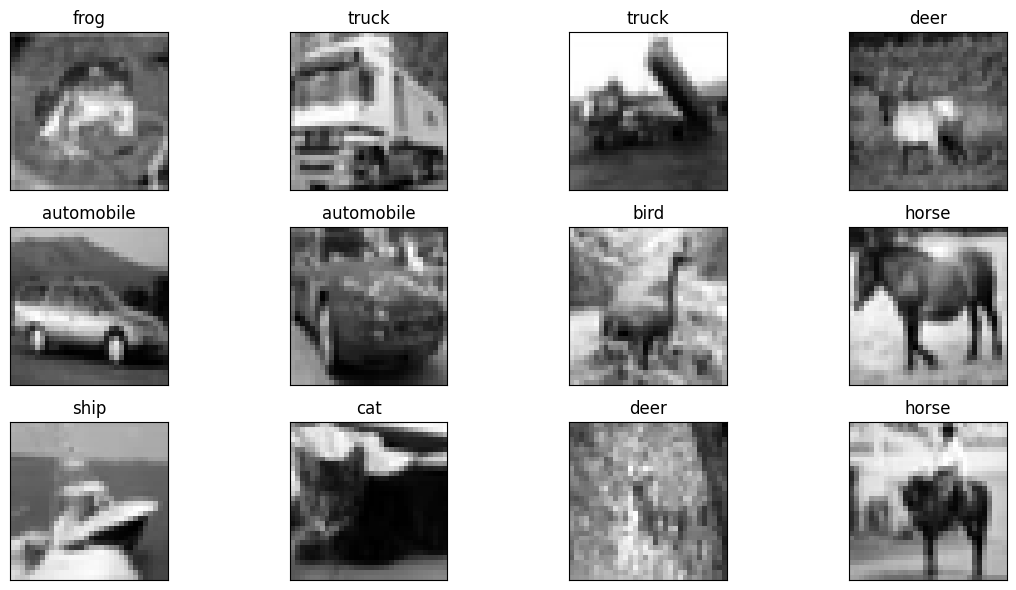

In [6]:
plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()


---
# 2. Construir la red neuronal

Construiremos la misma arquitectura conceptual vista en clase:

```text
Imagen 32×32
   ↓
Flatten
   ↓
1024 valores
   ↓
Dense(128)
   ↓
ReLU
   ↓
Dense(10)
   ↓
Logits
```

> La última capa **no** debe tener Softmax. Trabajaremos con logits.


In [8]:
# TODO 2 — Completa la arquitectura
model = keras.Sequential([
    #indicamos el tamaño de la imagen
    keras.Input(shape=(32, 32)),
    #aplanamos
    layers.Flatten(),
    # se usa 128 porque asi lo indica el diagrama/paso a paso; y se utiliza relu
    # por el mismo motivo
    layers.Dense(128, activation="relu"),
    #se le indica el numero de salidas que va a tener( numero de categorias)
    layers.Dense(10)
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,490 (517.54 KB)

 Trainable params: 132,490 (517.54 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Validación TODO 2
expected_params = (1024 * 128 + 128) + (128 * 10 + 10)
assert model.count_params() == expected_params
print(f"✓ Arquitectura correcta: {model.count_params():,} parámetros")


✓ Arquitectura correcta: 132,490 parámetros


### Preguntas

**2.** ¿Por qué necesitamos `Flatten()` antes de la primera capa `Dense`?

**Respuesta:** se necesita "flatten()" para facilitarle a la maquina realizar operaciones matriciales, dicho de otra forma, para que le sea mas facil "entender" o interpretar la informacion


**3.** ¿Por qué la última capa tiene 10 neuronas?

**Respuesta:** dado que el resultado son probabilidades de que una imagen pertenezca a una categoria u otra, el numero de neuronas necesarias para la salida en la ultima capa son equivalentes al numero de categorias disponibles


**4.** ¿Qué función cumple `ReLU`?

**Respuesta:** ReLU le limita a la maquina que informacion puede "ver" y cual no,lo que permite que la maquina se enfoque en cierta informacion y "aprenda" a detectar patrones



---
# 3. Configurar el entrenamiento

Usaremos:

- `Adam`
- `SparseCategoricalCrossentropy`
- `accuracy`

Como la red produce logits, la pérdida debe configurarse con `from_logits=True`.


In [11]:
lr_rate = 0.001

# TODO 3 — Configura el entrenamiento
model.compile(
    #le indicamos el algoritmo a utilizar, y el learning rate
    optimizer=keras.optimizers.Adam(learning_rate=lr_rate),
    # le indicamos como evaluar las salidas, y la manera en la que recibe los datos
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    # le indicamos que metrica utilizar, en este caso, el porcentaje de aciertos
    metrics=["accuracy"]
)


### Pregunta 5

¿Por qué usamos `from_logits=True`?

**Respuesta:** porque asi le indicamos al programa que "SparseCategoricalCrossentropy" debe usar la salida directa de el modelo como datos directos y no intentar interpretarla como probabilidades; de modo que la funcion misma haga el calculo.





---
# 4. Entrenar el modelo

Usaremos 10 épocas y mini-batches de 64 ejemplos. Completa `fit()`.


In [13]:
epochs = 10
batch_size = 64

# TODO 4 — Entrenamiento
history = model.fit(
    #definimos las caraterisiticas y las etiquetas (X y Y)
    X_train,
    y_train,
    #asignamos los valores
    epochs=epochs,
    batch_size=batch_size,
    #definimos lo valores con los que validar
    validation_data=(X_test, y_test),
    shuffle=True
)


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.2479 - loss: 2.0638 - val_accuracy: 0.2930 - val_loss: 1.9762
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3058 - loss: 1.9394 - val_accuracy: 0.3243 - val_loss: 1.9025
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.3286 - loss: 1.8870 - val_accuracy: 0.3304 - val_loss: 1.8681
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3439 - loss: 1.8498 - val_accuracy: 0.3407 - val_loss: 1.8454
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.3546 - loss: 1.8222 - val_accuracy: 0.3493 - val_loss: 1.8269
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3617 - loss: 1.8030 - val_accuracy: 0.3530 - val_loss: 1.8120
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.3698 - loss: 1.7856 - val_accuracy: 0.3578 - val_loss: 1.7983
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3755 - loss: 1.7720 - val_accuracy: 0.

### Preguntas

**6.** ¿Qué representa una `epoch`?

**Respuesta:** un recorrido de el dataset completo


**7.** ¿Qué representa `batch_size=64`?

**Respuesta:** el numero de ejemplos que se procesan en grupo durante el epoch antes de que se actualicen los pesos



## 4.1 Curvas de aprendizaje

Esta parte está resuelta.


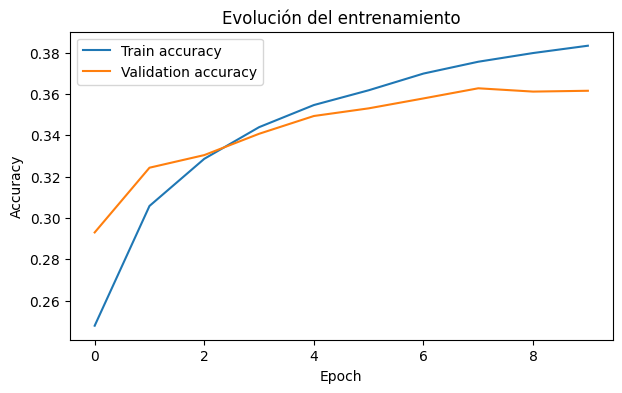

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Evolución del entrenamiento")
plt.legend()
plt.show()


### Pregunta 8

Observa las dos curvas. ¿Hay evidencia de overfitting? Justifica brevemente.

**Respuesta:** "no hay evidencia de overfitting, ya que, aunque se empieza a generar una brecha en la curva de aprendizaje y valor, esta no es lo suficientemente grande para indicar overfitting



---
# 5. Evaluar el modelo

Completa `evaluate()`.


In [15]:
# TODO 5 — Evaluación
test_loss, test_accuracy = model.evaluate(
    #definimos los dataset a usar
    X_test,
    y_test,
    batch_size=batch_size,
    verbose=0
)

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")
print(f"Accuracy (%)  : {test_accuracy * 100:.2f}%")


Test loss     : 1.7884
Test accuracy : 0.3615
Accuracy (%)  : 36.15%


### Pregunta 9

Compara este resultado con Fashion-MNIST, utilizado en clase.

¿CIFAR-10 en escala de grises parece más fácil o más difícil para esta red? Justifica usando el accuracy obtenido.

**Respuesta:**



---
# 6. Logits y Softmax

La salida de la red son 10 logits. Para interpretarlos como probabilidades necesitamos Softmax.


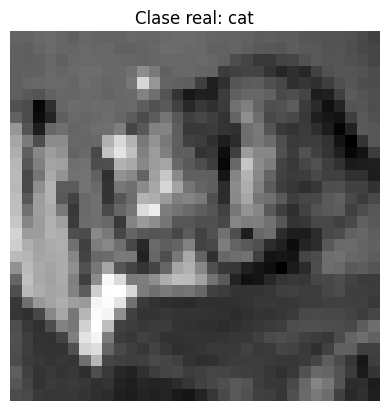

Logits:
[[ 1.0590694  -1.5264024   1.5041101   0.17534186  1.2074449   0.14354268
   0.41668248  0.43064484 -0.11366481 -1.9202516 ]]


In [16]:
index = 0
image = X_test[index]
true_class = y_test[index]

plt.imshow(image, cmap="gray")
plt.title(f"Clase real: {class_names[true_class]}")
plt.axis("off")
plt.show()

image_batch = np.expand_dims(image, axis=0)
logits = model(image_batch, training=False)

print("Logits:")
print(keras.ops.convert_to_numpy(logits))


In [18]:
# TODO 6 — Logits -> probabilidades
probabilities = keras.ops.softmax(logits)

# TODO 7 — Clase con mayor probabilidad
prediction = keras.ops.argmax(probabilities, axis=1)
prediction = int(keras.ops.convert_to_numpy(prediction)[0])

print("Clase real     :", class_names[true_class])
print("Clase predicha :", class_names[prediction])


Clase real     : cat
Clase predicha : bird


In [19]:
probabilities_np = keras.ops.convert_to_numpy(probabilities)[0]

print("\nProbabilidades:")
for i, p in enumerate(probabilities_np):
    marker = " ← predicción" if i == prediction else ""
    print(f"{class_names[i]:12s}: {p:.4f}{marker}")

print("\nSuma:", probabilities_np.sum())



Probabilidades:
airplane    : 0.1659
automobile  : 0.0125
bird        : 0.2588 ← predicción
cat         : 0.0685
deer        : 0.1924
dog         : 0.0664
frog        : 0.0872
horse       : 0.0885
ship        : 0.0513
truck       : 0.0084

Suma: 1.0


### Pregunta 10

¿Por qué las probabilidades producidas por `Softmax` deben sumar aproximadamente 1?

**Respuesta:** porque las probabilidades generadas por softmax representan la probabilidad de el dato ingresado de pertenecer a cada categoria, por lo que la suma acomulada debe ser 1



---
# 7. Varias predicciones

Esta parte está resuelta. Observa especialmente los errores del modelo.


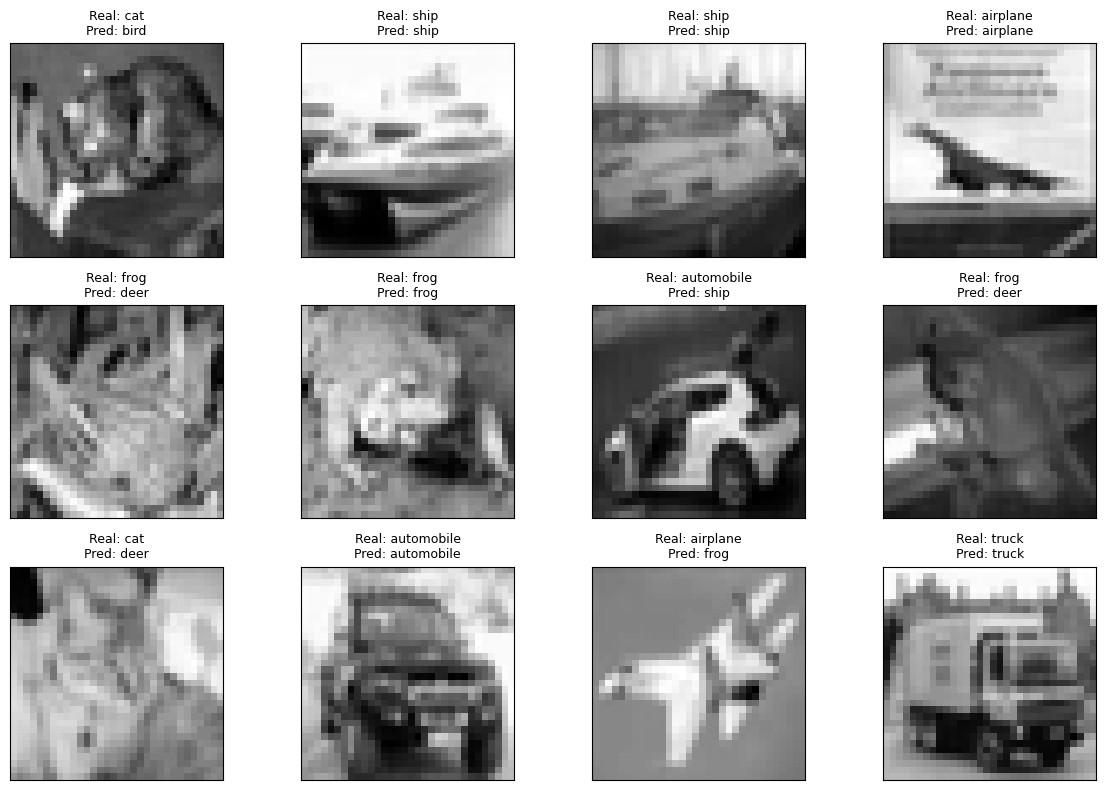

In [21]:
n = 12
logits_batch = model(X_test[:n], training=False)
predictions = keras.ops.argmax(logits_batch, axis=1)
predictions = keras.ops.convert_to_numpy(predictions)

plt.figure(figsize=(12, 8))
for i in range(n):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    real = class_names[y_test[i]]
    pred = class_names[predictions[i]]
    plt.title(f"Real: {real}\nPred: {pred}", fontsize=9)
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()


---
# 8. Reflexión final

### 1. ¿Cuál fue el accuracy final?

**Respuesta:**


### 2. ¿Qué clases parecen más difíciles de distinguir?

**Respuesta:** las clases que comparten caracteristicas entre si, que pertenecen a un macrogrupo, en este caso, animales | vehiculos, ya que comparten caracteristicas entre si, esto se debe a que las imagenes pierden informacion que puede ayudar adiferenciarles entre so, como por eljemplo el color, y dado a la transformacion realizada, pierden resolucion


### 3. Después de `Flatten()`, la imagen se convierte en un vector de 1024 valores. ¿Qué información importante sobre la imagen podría perderse al tratarla únicamente como un vector?

**Respuesta:** La informacion espacial relacionada a la posicion de el pixel, dado que flatten los transforma a una matriz de 1xN, lo que dificulta identificar informacion como los bordes


### 4. ¿Qué tipo de arquitectura podría aprovechar mejor la estructura espacial de las imágenes?

**Respuesta:** Convolutional Neural Networks (CNNs)

---

## Para pensar

Nuestro modelo hace:

```text
32×32 → Flatten → 1024 valores → Dense → ReLU → Dense(10)
```

Sin embargo, una imagen tiene **estructura espacial**: existen bordes, formas y patrones locales.

Este resultado nos deja preparada la siguiente pregunta del curso:

> **¿Cómo puede una red aprovechar directamente la estructura espacial de una imagen?**

La respuesta será: **Convolutional Neural Networks (CNNs)**.
